# Books for Life Moments

## 1. Data Collection

This project builds a book recommendation system based on emotional needs and life situations.

We will collect:
- Book metadata (title, author, rating, genres)
- Book descriptions
- User reviews (for NLP sentiment & emotional analysis)

Sources:
- Goodreads (scraping)
- Books API (e.g., Open Library / Google Books)

Goal:
Build a dataset of ~300–1000 books for analysis and recommendation.

In [28]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

print("Set up ok")

Set up ok


In [8]:
import time

base_url = "http://books.toscrape.com/catalogue/page-{}.html"

books = []

for page in range(1, 6):  # 5 páginas (~100 libros)
    
    url = base_url.format(page)
    response = requests.get(url)
    soup = BeautifulSoup(response.content, "html.parser")
    
    book_items = soup.find_all("article", class_="product_pod")
    
    for book in book_items:
        
        title = book.h3.a["title"]
        price = book.find("p", class_="price_color").text
        rating = book.p["class"][1]  # e.g. One, Two, Three
        link = book.h3.a["href"]
        
        books.append({
            "title": title,
            "price": price,
            "rating_text": rating,
            "link": link
        })
    
    time.sleep(1)

df = pd.DataFrame(books)
df.head()

,title,price,rating_text,link
0,A Light in the Attic,£51.77,Three,a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,£53.74,One,tipping-the-velvet_999/index.html
2,Soumission,£50.10,One,soumission_998/index.html
3,Sharp Objects,£47.82,Four,sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,£54.23,Five,sapiens-a-brief-history-of-humankind_996/index...


In [9]:
df.to_csv("../data/raw/books.csv", index=False)
print("Dataset guardado en data/raw/books.csv")

Dataset guardado en data/raw/books.csv


In [11]:
import pandas as pd
import requests
import time

df = pd.read_csv("../data/raw/books.csv")

descriptions = []
authors = []
subjects = []

for i, title in enumerate(df["title"]):

    try:
        url = f"https://openlibrary.org/search.json?title={title}"
        res = requests.get(url, timeout=10).json()

        doc = res["docs"][0] if res["docs"] else {}

        descriptions.append(doc.get("first_sentence", [""])[0] if "first_sentence" in doc else "")
        authors.append(doc.get("author_name", ["Unknown"])[0])
        subjects.append(", ".join(doc.get("subject", [])[:5]) if "subject" in doc else "")

    except:
        descriptions.append("")
        authors.append("Unknown")
        subjects.append("")

    time.sleep(1)

df["author"] = authors
df["description"] = descriptions
df["genres"] = subjects

df.head()

,title,price,rating_text,link,author,description,genres
0,A Light in the Attic,£51.77,Three,a-light-in-the-attic_1000/index.html,Shel Silverstein,,
1,Tipping the Velvet,£53.74,One,tipping-the-velvet_999/index.html,Sarah Waters,,
2,Soumission,£50.10,One,soumission_998/index.html,Michel Houellebecq,,
3,Sharp Objects,£47.82,Four,sharp-objects_997/index.html,Gillian Flynn,,
4,Sapiens: A Brief History of Humankind,£54.23,Five,sapiens-a-brief-history-of-humankind_996/index...,BookNation,,


In [14]:
df.to_csv("../data/processed/books_enriched.csv", index=False)
print("Guardado correcto en processed")

Guardado correcto en processed


In [15]:
import os
print(os.listdir("../data/processed"))

['books_enriched.csv']


In [16]:
import pandas as pd

df = pd.read_csv("../data/processed/books_enriched.csv")
df.head()

,title,price,rating_text,link,author,description,genres
0,A Light in the Attic,£51.77,Three,a-light-in-the-attic_1000/index.html,Shel Silverstein,NaN,NaN
1,Tipping the Velvet,£53.74,One,tipping-the-velvet_999/index.html,Sarah Waters,NaN,NaN
2,Soumission,£50.10,One,soumission_998/index.html,Michel Houellebecq,NaN,NaN
3,Sharp Objects,£47.82,Four,sharp-objects_997/index.html,Gillian Flynn,NaN,NaN
4,Sapiens: A Brief History of Humankind,£54.23,Five,sapiens-a-brief-history-of-humankind_996/index...,BookNation,NaN,NaN


In [17]:
df["content"] = (
    df["title"].fillna("") + " " +
    df["author"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["genres"].fillna("")
)

df[["title", "content"]].head()

,title,content
0,A Light in the Attic,A Light in the Attic Shel Silverstein
1,Tipping the Velvet,Tipping the Velvet Sarah Waters
2,Soumission,Soumission Michel Houellebecq
3,Sharp Objects,Sharp Objects Gillian Flynn
4,Sapiens: A Brief History of Humankind,Sapiens: A Brief History of Humankind BookNati...


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=3000)

tfidf_matrix = tfidf.fit_transform(df["content"])

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(tfidf_matrix)

In [20]:
def recommend(book_title, df, similarity_matrix):
    idx = df[df["title"] == book_title].index[0]
    
    scores = list(enumerate(similarity_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]
    
    return [df.iloc[i[0]]["title"] for i in scores]

In [21]:
recommend(df["title"].iloc[0], df, similarity)

['Tipping the Velvet',
 'Soumission',
 'Sharp Objects',
 'Sapiens: A Brief History of Humankind',
 'The Requiem Red']

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df["cluster"] = kmeans.fit_predict(tfidf_matrix)

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(tfidf_matrix.toarray())

In [25]:
df["x"] = reduced[:, 0]
df["y"] = reduced[:, 1]

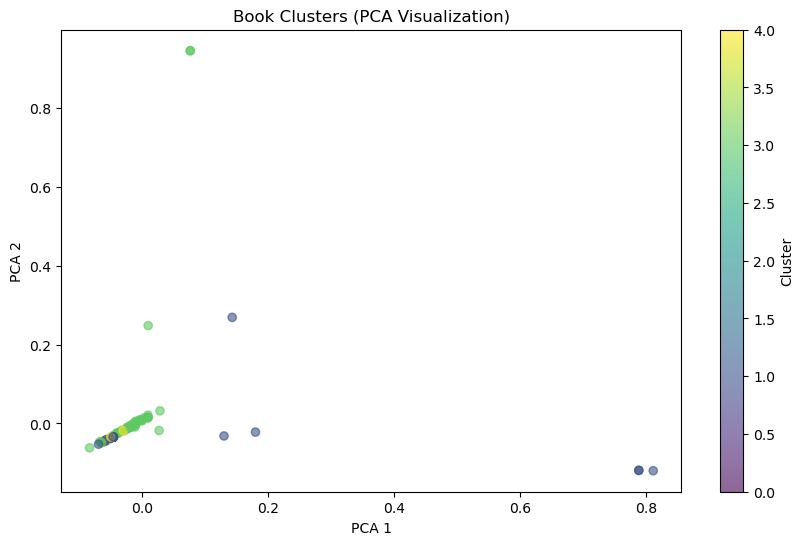

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(df["x"], df["y"], c=df["cluster"], cmap="viridis", alpha=0.6)

plt.title("Book Clusters (PCA Visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.colorbar(label="Cluster")
plt.show()

In [27]:
import pandas as pd

df = pd.read_csv("../data/processed/books_enriched.csv")
print(df.columns)
df.head()

Index(['title', 'price', 'rating_text', 'link', 'author', 'description',
       'genres'],
      dtype='object')


,title,price,rating_text,link,author,description,genres
0,A Light in the Attic,£51.77,Three,a-light-in-the-attic_1000/index.html,Shel Silverstein,NaN,NaN
1,Tipping the Velvet,£53.74,One,tipping-the-velvet_999/index.html,Sarah Waters,NaN,NaN
2,Soumission,£50.10,One,soumission_998/index.html,Michel Houellebecq,NaN,NaN
3,Sharp Objects,£47.82,Four,sharp-objects_997/index.html,Gillian Flynn,NaN,NaN
4,Sapiens: A Brief History of Humankind,£54.23,Five,sapiens-a-brief-history-of-humankind_996/index...,BookNation,NaN,NaN


In [29]:
import os

os.listdir()

['.ipynb_checkpoints', '01_data_collection.ipynb']